# Traffic Volume Analysis

## Cleaning & feature Engineering

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


from keras.models import Sequential
from keras.layers import GRU, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import xgboost as xgb


# Set style for better visualizations
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 📂 Step 1: Load and Explore the Dataset

- Load the traffic volume dataset from CSV.
- Display basic information using `.info()` and `.describe()`.
- Show the first few rows of the dataset to understand the data structure.

---

In [89]:
# Read the dataset
print("Loading data...")
df = pd.read_csv(r'/content/Metro_Interstate_Traffic_Volume.csv')

# Display basic information
print("\nDataset Info:")
print(df.info())

print("\nFirst few rows:")
df.head()

Loading data...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              61 non-null     object 
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  object 
 7   weather_description  48204 non-null  object 
 8   date_time            48204 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
None

First few rows:


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [90]:
# Display basic information
print("\nDataset describe:")
df.describe().round(2)


Dataset describe:


,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.00,48204.00,48204.00,48204.00,48204.00
mean,3259.82,281.21,0.33,0.00,49.36
std,1986.86,13.34,44.79,0.01,39.02
min,0.00,0.00,0.00,0.00,0.00
25%,1193.00,272.16,0.00,0.00,1.00
50%,3380.00,282.45,0.00,0.00,64.00
75%,4933.00,291.81,0.00,0.00,90.00
max,7280.00,310.07,9831.30,0.51,100.00


## 🛠️ Step 2: Data Cleaning

### 🔹 Convert date_time column:
- Convert the `date_time` column to **datetime format** for easier manipulation.

### 🔹 Handle missing values:
- For **categorical columns** (`holiday`, `weather_main`, `weather_description`):
  - Fill missing values with `"No Holiday"` or the **mode** of the column.
- For **numeric columns** (`temp`, `rain_1h`, `snow_1h`, `clouds_all`):
  - Fill missing values with the **median**, as it is less sensitive to outliers.

---

## 🕐 Step 3: Feature Engineering (Extract Time Features)

- Extract useful time-based features from `date_time`:
  - `hour`: Hour of the day (0-23).
  - `day_of_week`: Day name (Monday, Tuesday, etc.).
  - `month`: Month number.
  - `year`: Year of the data.
  - `season`: Season derived from the month (`Winter`, `Spring`, `Summer`, `Fall`).

---

## 🌡️ Step 4: Temperature Conversion and Categorization

- Convert temperature from **Kelvin to Celsius**:  
  `temp_celsius = temp - 273.15`
- Create temperature categories:
  - Very Cold (≤0°C)
  - Cold (0-10°C)
  - Mild (10-20°C)
  - Warm (20-30°C)
  - Hot (>30°C)

---

## ✅ Step 5: Final Check for Missing Values

- Display the count of missing values after cleaning to ensure the dataset is ready for modeling.


In [91]:
# Data Cleaning
print("\nCleaning data...")
# Convert date_time to datetime
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

# Fill missing values
df['holiday'] = df['holiday'].fillna('No Holiday')
df['weather_main'] = df['weather_main'].fillna(df['weather_main'].mode()[0])
df['weather_description'] = df['weather_description'].fillna(df['weather_description'].mode()[0])

# Fill missing numeric values with median
numeric_columns = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Add time-based features
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['season'] = pd.cut(df['month'],
                      bins=[0, 3, 6, 9, 12],
                      labels=['Winter', 'Spring', 'Summer', 'Fall'])

# Convert temperature from Kelvin to Celsius
df['temp_celsius'] = df['temp'] - 273.15

# Create temperature categories
df['temp_category'] = pd.cut(df['temp_celsius'],
                            bins=[-float('inf'), 0, 10, 20, 30, float('inf')],
                            labels=['Very Cold (≤0°C)', 'Cold (0-10°C)',
                                   'Mild (10-20°C)', 'Warm (20-30°C)',
                                   'Hot (>30°C)'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Cleaning data...

Missing values after cleaning:
traffic_volume         0
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
hour                   0
day_of_week            0
month                  0
year                   0
season                 0
temp_celsius           0
temp_category          0
dtype: int64


# 📈 Exploratory Data Analysis (EDA)

---

## Analysis of metro interstate traffic patterns and their relationship with weather conditions.




### 🔍 1. Analyze Hourly Traffic Patterns

- Calculate the **average traffic volume by hour of the day**.
- Visualize using a bar chart.
- Identify the **peak traffic hour** and the **lowest traffic hour**.



Creating hourly traffic plot...
Peak traffic hour: 16:00 with 5664 vehicles
Lowest traffic hour: 3:00 with 371 vehicles


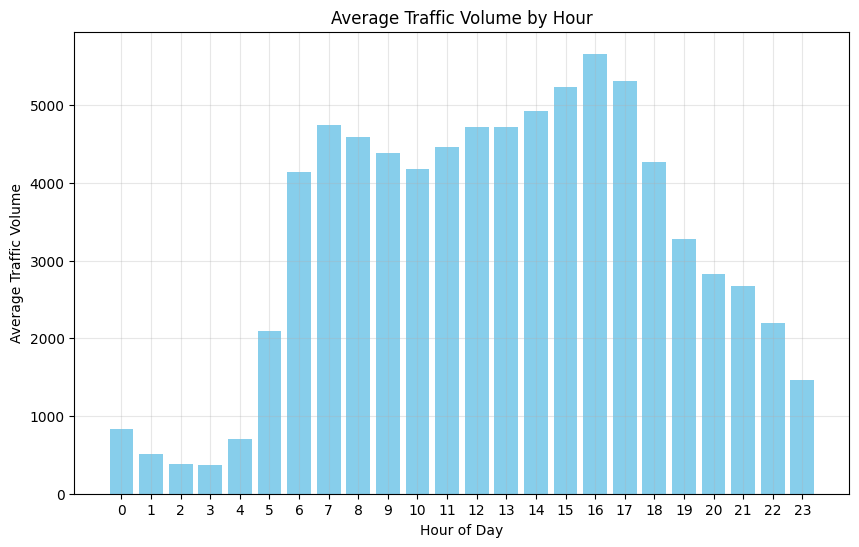

In [92]:
print("Creating hourly traffic plot...")
hourly_traffic = df.groupby('hour')['traffic_volume'].mean()

plt.figure()
plt.bar(hourly_traffic.index, hourly_traffic.values, color='skyblue')
plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

# Find and display peak and lowest traffic hours
peak_hour = hourly_traffic.idxmax()
peak_traffic = hourly_traffic.max()
lowest_hour = hourly_traffic.idxmin()
lowest_traffic = hourly_traffic.min()

print(f"Peak traffic hour: {peak_hour}:00 with {peak_traffic:.0f} vehicles")
print(f"Lowest traffic hour: {lowest_hour}:00 with {lowest_traffic:.0f} vehicles")
plt.show()

### 🔍 2. Analyze Daily Traffic Patterns

- Calculate the **average traffic volume for each day of the week**.
- Sort days in calendar order (Monday to Sunday).
- Visualize using a bar chart.
- Compare **weekday vs weekend** traffic volumes.

---



Creating daily traffic plot...

Weekday vs Weekend Traffic:
Weekday average: 3535 vehicles
Weekend average: 2571 vehicles


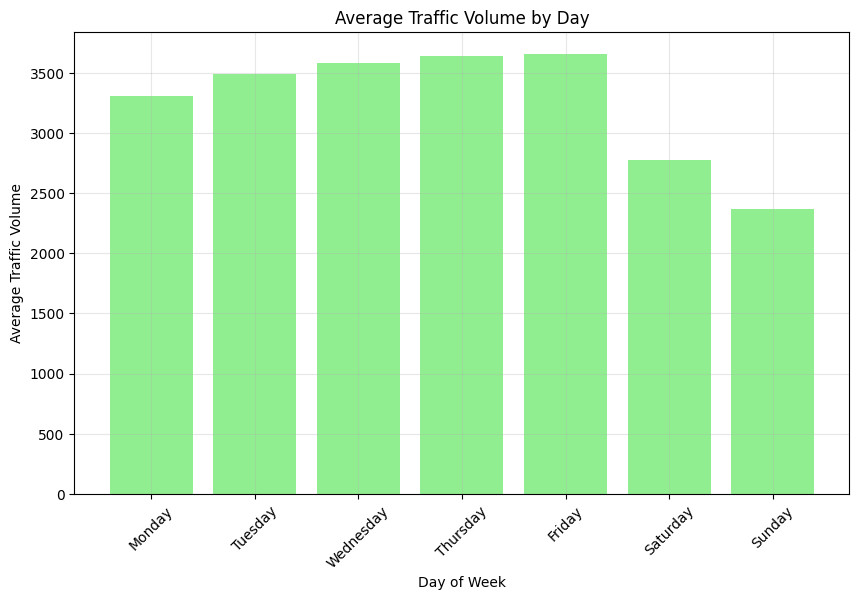

In [93]:
print("\nCreating daily traffic plot...")
# Order days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_traffic = df.groupby('day_of_week')['traffic_volume'].mean()
daily_traffic = daily_traffic.reindex(days_order)

plt.figure()
plt.bar(daily_traffic.index, daily_traffic.values, color='lightgreen')
plt.title('Average Traffic Volume by Day')
plt.xlabel('Day of Week')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Calculate weekday vs weekend averages
weekday_traffic = daily_traffic[:5].mean()
weekend_traffic = daily_traffic[5:].mean()

print("\nWeekday vs Weekend Traffic:")
print(f"Weekday average: {weekday_traffic:.0f} vehicles")
print(f"Weekend average: {weekend_traffic:.0f} vehicles")
plt.show()


### 🔍 3. Analyze Weather Impact on Traffic

- Calculate the **average traffic volume by weather condition**.
- Visualize using a horizontal bar chart.
- Identify the top 3 weather conditions with the highest traffic.

---



Creating weather impact plot...

Top 3 weather conditions with highest traffic:
Clouds: 3618 vehicles
Haze: 3502 vehicles
Rain: 3318 vehicles


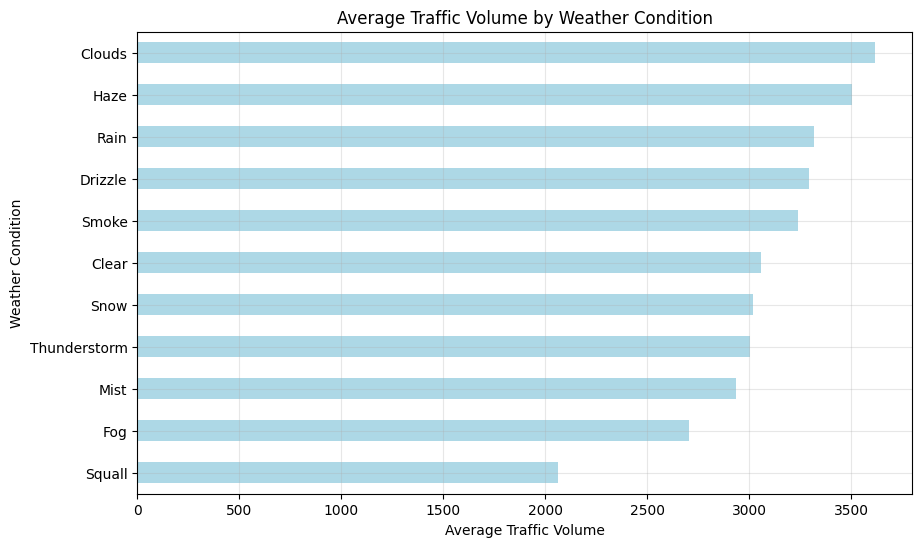

In [94]:
print("\nCreating weather impact plot...")
weather_traffic = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=True)

plt.figure(figsize=[10, 6])
weather_traffic.plot(kind='barh', color='lightblue')
plt.title('Average Traffic Volume by Weather Condition')
plt.xlabel('Average Traffic Volume')
plt.ylabel('Weather Condition')
plt.grid(True, alpha=0.3)

print("\nTop 3 weather conditions with highest traffic:")
for weather, traffic in weather_traffic.tail(3)[::-1].items():
    print(f"{weather}: {traffic:.0f} vehicles")
plt.show()


### 🔍 4. Analyze Monthly Traffic Trends

- Calculate the **average traffic volume by month**.
- Visualize using a line plot to observe **seasonal trends**.

---



Creating monthly trends plot...


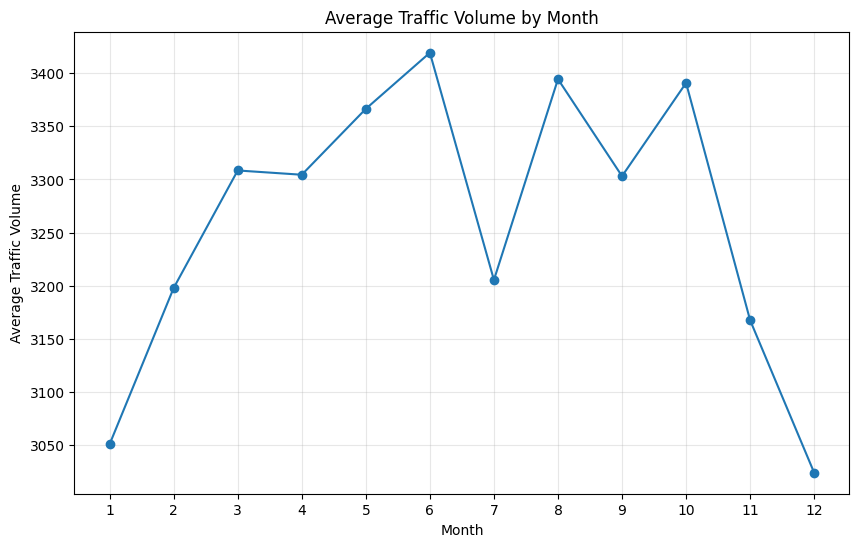

In [95]:
print("\nCreating monthly trends plot...")
monthly_traffic = df.groupby('month')['traffic_volume'].mean()

plt.figure()
plt.plot(monthly_traffic.index, monthly_traffic.values, marker='o')
plt.title('Average Traffic Volume by Month')
plt.xlabel('Month')
plt.ylabel('Average Traffic Volume')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.show()


### 🔍 5. Analyze Temperature Impact on Traffic

#### 5.1 Basic Relationship:
- Scatter plot showing the relationship between **temperature (°C)** and **traffic volume**.
- Add a **trend line**.
- Calculate the **correlation coefficient** between temperature and traffic volume.

#### 5.2 Traffic by Temperature Categories:
- Group by predefined **temperature categories** (`Very Cold`, `Cold`, etc.).
- Plot the **average traffic volume** for each category.

#### 5.3 Seasonal & Temperature Interaction:
- Analyze how **traffic volume varies across seasons and temperature categories**.
- Create a grouped bar chart to visualize patterns.

#### 5.4 Temperature Impact by Hour:
- Analyze how **traffic volume varies across hours of the day and temperature categories**.
- Create a multi-line chart showing hourly traffic trends by temperature category.

---

### 🔍 6. Additional Traffic Statistics

- Identify **peak traffic hours for each temperature category**.
- Analyze **rush hour (8 AM, 4-6 PM) traffic** based on temperature.

---




Creating temperature analysis plots...


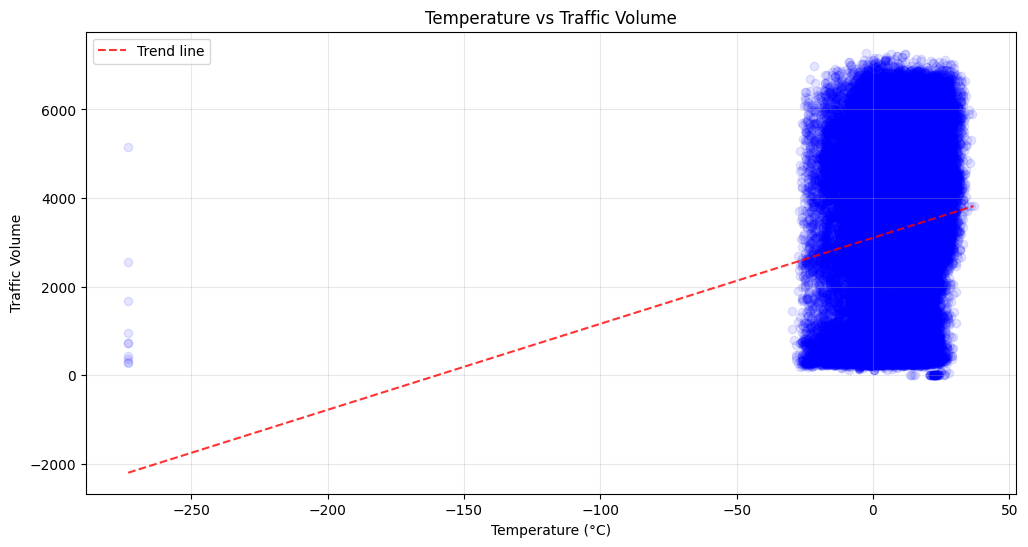


Correlation between temperature and traffic: 0.130
Temperature range: -273.1°C to 36.9°C


/tmp/ipython-input-96-4215889657.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_cat_traffic = df.groupby('temp_category')['traffic_volume'].agg(['mean', 'std', 'count'])


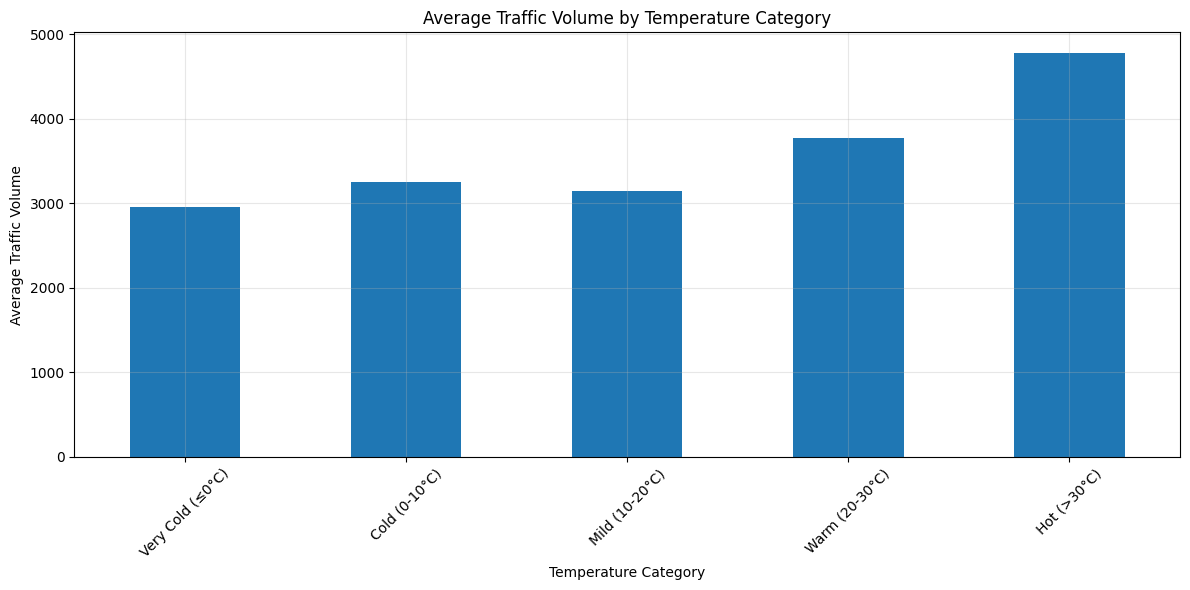


Traffic statistics by temperature category:
                         mean          std  count
temp_category                                    
Very Cold (≤0°C)  2961.470650  1962.480292  13373
Cold (0-10°C)     3254.768687  2031.157394  11318
Mild (10-20°C)    3148.265924  2069.463985  13549
Warm (20-30°C)    3776.948965  1735.804439   9562
Hot (>30°C)       4786.129353  1017.836843    402


/tmp/ipython-input-96-4215889657.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_temp_traffic = df.groupby(['season', 'temp_category'])['traffic_volume'].mean().unstack()


<Figure size 1200x600 with 0 Axes>

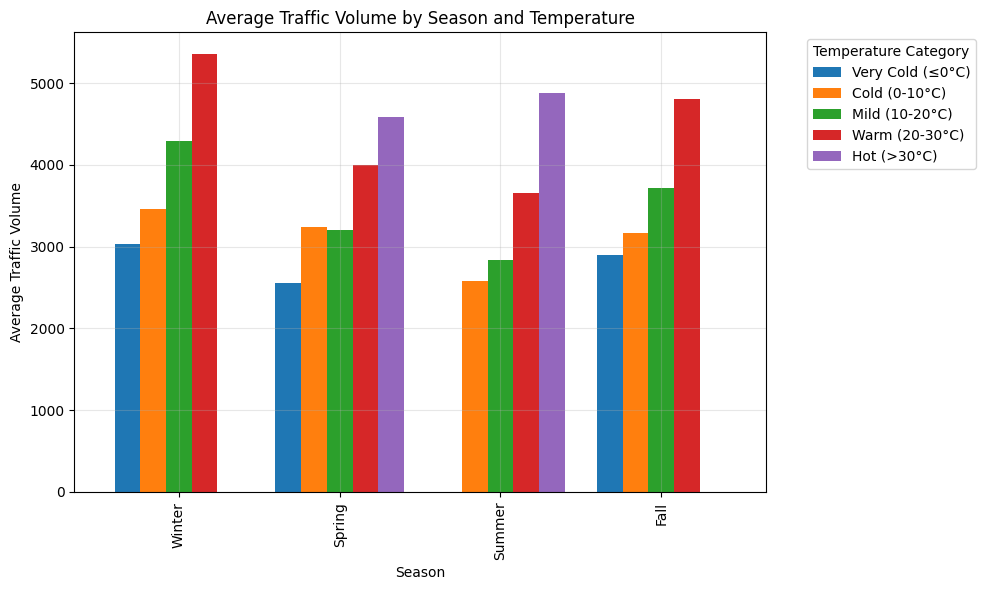

/tmp/ipython-input-96-4215889657.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_temp_hour = df.pivot_table(values='traffic_volume',


<Figure size 1500x600 with 0 Axes>

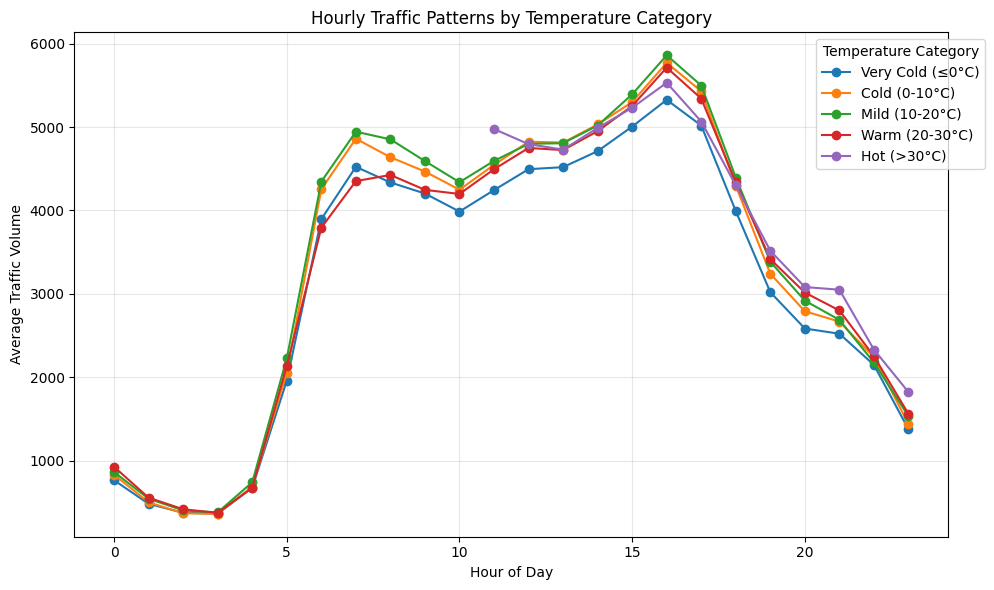


Peak Traffic Hours by Temperature Category:
Very Cold (≤0°C): 16:00 (5327 vehicles)
Cold (0-10°C): 16:00 (5771 vehicles)
Mild (10-20°C): 16:00 (5861 vehicles)
Warm (20-30°C): 16:00 (5713 vehicles)
Hot (>30°C): 16:00 (5532 vehicles)

Rush Hour Traffic by Temperature:
temp_category
Very Cold (≤0°C)    4627.512244
Cold (0-10°C)       5025.636512
Mild (10-20°C)      5096.286320
Warm (20-30°C)      5053.121065
Hot (>30°C)         5028.390000
Name: traffic_volume, dtype: float64


/tmp/ipython-input-96-4215889657.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rush_hour_temp = rush_hours.groupby('temp_category')['traffic_volume'].mean()


In [96]:
print("\nCreating temperature analysis plots...")

# 1. Basic Temperature vs Traffic Plot
plt.figure(figsize=(12, 6))
plt.scatter(df['temp_celsius'], df['traffic_volume'], alpha=0.1, color='blue')
plt.title('Temperature vs Traffic Volume')
plt.xlabel('Temperature (°C)')
plt.ylabel('Traffic Volume')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['temp_celsius'], df['traffic_volume'], 1)
p = np.poly1d(z)
plt.plot(df['temp_celsius'].sort_values(),
         p(df['temp_celsius'].sort_values()),
         "r--",
         alpha=0.8,
         label='Trend line')
plt.legend()
plt.show()

# Calculate correlation
correlation = df['temp_celsius'].corr(df['traffic_volume'])
print(f"\nCorrelation between temperature and traffic: {correlation:.3f}")
print(f"Temperature range: {df['temp_celsius'].min():.1f}°C to {df['temp_celsius'].max():.1f}°C")

# 2. Temperature Categories Analysis
plt.figure(figsize=(12, 6))
temp_cat_traffic = df.groupby('temp_category')['traffic_volume'].agg(['mean', 'std', 'count'])
temp_cat_traffic['mean'].plot(kind='bar')
plt.title('Average Traffic Volume by Temperature Category')
plt.xlabel('Temperature Category')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTraffic statistics by temperature category:")
print(temp_cat_traffic)

# 3. Seasonal Temperature Patterns
plt.figure(figsize=(12, 6))
seasonal_temp_traffic = df.groupby(['season', 'temp_category'])['traffic_volume'].mean().unstack()
seasonal_temp_traffic.plot(kind='bar', width=0.8)
plt.title('Average Traffic Volume by Season and Temperature')
plt.xlabel('Season')
plt.ylabel('Average Traffic Volume')
plt.legend(title='Temperature Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 4. Temperature Impact by Hour
plt.figure(figsize=(15, 6))
pivot_temp_hour = df.pivot_table(values='traffic_volume',
                                index='hour',
                                columns='temp_category',
                                aggfunc='mean')
pivot_temp_hour.plot(marker='o')
plt.title('Hourly Traffic Patterns by Temperature Category')
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')
plt.legend(title='Temperature Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Additional Statistics
print("\nPeak Traffic Hours by Temperature Category:")
for temp_cat in pivot_temp_hour.columns:
    peak_hour = pivot_temp_hour[temp_cat].idxmax()
    peak_volume = pivot_temp_hour[temp_cat].max()
    print(f"{temp_cat}: {peak_hour}:00 ({peak_volume:.0f} vehicles)")

# Temperature effects on rush hour traffic
rush_hours = df[df['hour'].isin([8, 16, 17, 18])]  # Morning and evening rush hours
rush_hour_temp = rush_hours.groupby('temp_category')['traffic_volume'].mean()

print("\nRush Hour Traffic by Temperature:")
print(rush_hour_temp)

In [97]:
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,hour,day_of_week,month,year,season,temp_celsius,temp_category
0,5545,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,9,Tuesday,10,2012,Fall,15.13,Mild (10-20°C)
1,4516,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,10,Tuesday,10,2012,Fall,16.21,Mild (10-20°C)
2,4767,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,11,Tuesday,10,2012,Fall,16.43,Mild (10-20°C)
3,5026,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,12,Tuesday,10,2012,Fall,16.98,Mild (10-20°C)
4,4918,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,13,Tuesday,10,2012,Fall,17.99,Mild (10-20°C)


## ⚙️  Feature Engineering and Data Preparation

---

### 🔧1 Convert Categorical Columns to Numerical

- **Convert 'holiday' to a binary feature:**
  - 1 if it's a holiday, 0 otherwise → new column: `is_holiday`.

- **Convert categorical variables to dummy variables (One-Hot Encoding):**
  - `weather_main`, `temp_category`, and `season`.
  - Use `drop_first=True` to avoid the dummy variable trap.

---

### 🔧2 Create Additional Time Features

- `dayofweek`: Numeric day of the week (Monday = 0, Sunday = 6).
- `is_weekend`: 1 if the day is Saturday or Sunday, 0 otherwise.

---


In [98]:
# Convert 'holiday' to binary feature
df['is_holiday'] = (df['holiday'] != 'No Holiday').astype(int)
# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=['weather_main','temp_category','season'], drop_first=True)
# Create additional features
df['dayofweek'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)


### 🧹 3 Drop Unused Columns

Remove columns that won't be used in modeling:
- `'date_time'`: Already extracted useful time features.
- `'holiday'`: Converted to `is_holiday`.
- `'temp'`: Already converted to `temp_celsius`.
- `'weather_description'`: Too detailed; using `weather_main` instead.
- `'day_of_week'`: Already extracted as `dayofweek`.

---


In [99]:
# Drop unused columns
df_afterdrobing= df.drop(columns=['date_time', 'holiday', 'temp', 'weather_description','day_of_week'], axis= 1)


### ✅ Result:
At this stage, the dataset is fully numerical and ready for scaling and model training.


In [100]:
# df.to_csv('cleaned_traffic_data.csv', index=False)
# print("\nData cleaning and feature engineering completed. Cleaned data saved to 'cleaned_traffic_data.csv'.")

## 🔍 Modeling Approaches

To understand the problem from different perspectives, we applied both **classical machine learning** and **deep learning** models to predict hourly traffic volume:

---

### ✅ Classical ML Approach:
- **XGBoost Regressor:**  
  - Captures feature-level relationships.  
  - Suitable for structured/tabular data.  
  - Fast to train and easy to interpret.

---

### ✅ Deep Learning Approach:
- **LSTM / GRU Networks:**  
  - Designed to capture time-series dependencies.  
  - Can learn patterns from sequences of past hours.  
  - Better suited for modeling trends over time.

---

### 🎯 Purpose of Using Both:
- To **compare different modeling techniques** on the same problem.
- To find whether the traffic volume is better explained by static feature relationships (**XGBoost**) or time-sequential patterns (**LSTM / GRU**).


## 🚀  Train a Classical ML Model (XGBoost)

---

### 🔧 1 Define Features and Target

- `X`: All columns except `traffic_volume` (the target).
- `y`: The `traffic_volume` column.

---

### 🔀 2 Split the Dataset

- Split the dataset into **training (70%)** and **testing (30%)** sets.
- Use a `random_state` for reproducibility.

---

### ⚙️ 3 Train the XGBoost Regressor

- Used **XGBRegressor** with `reg:squarederror` as the objective.
- XGBoost is a **powerful and fast gradient boosting model**.

---

### 🔍 4 Make Predictions on Test Data

- Predict traffic volume using the trained model.
- The next step is to evaluate its performance using appropriate metrics.


In [101]:
# Define features and target
X = df_afterdrobing.drop(columns=['traffic_volume'])
y = df_afterdrobing['traffic_volume']



# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [102]:
# Train XGBoost Regressor
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)


# Predict and evaluate
y_pred = model.predict(X_test)

## 📊  Model Evaluation (XGBoost)

---

### ✅ 1 Evaluate on Test Set

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted values.
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more heavily.
- **R² Score:** Measures how well the model explains the variance in the target.

---


In [103]:
mae = mean_absolute_error(y_test, y_pred)
# Calculate MSE first, then take the square root for RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(229.81178283691406, np.float64(395.1330867568546), 0.960736095905304)


### ✅ 2 Evaluate on Training Set

- Repeated the same metrics on the training data to check for **overfitting**.

---


In [104]:
# Get predictions for training data first
y_train_pred = model.predict(X_train)

# Then calculate metrics
mae_tr = mean_absolute_error(y_train, y_train_pred)
# Calculate MSE first, then take the square root for RMSE
mse_tr = mean_squared_error(y_train, y_train_pred)
rmse_tr = np.sqrt(mse_tr)
r2_tr = r2_score(y_train, y_train_pred)

mae_tr, rmse_tr, r2_tr

(203.76084899902344, np.float64(343.61982762567703), 0.9699949026107788)


### ✅ 3 Summary of Results

| Metric  | Train Set | Test Set |
|--------|------------|----------|
| MAE    | 203.7608   | 229.8117 |
| RMSE   | 343.6198   | 395.1330 |
| R²     | 0.969994   | 0.960736 |



---

### 📈 4 Plot: Actual vs Predicted (First 100 Samples)

- Plotted the first 100 samples of the test set to visually assess the model's performance.
- A good model will have the predicted line closely following the actual line.

---

### 🎯 Interpretation:
- If the Train and Test scores are **close**, the model is likely not overfitting.
- If Test scores are much worse than Train scores, the model may be overfitting.


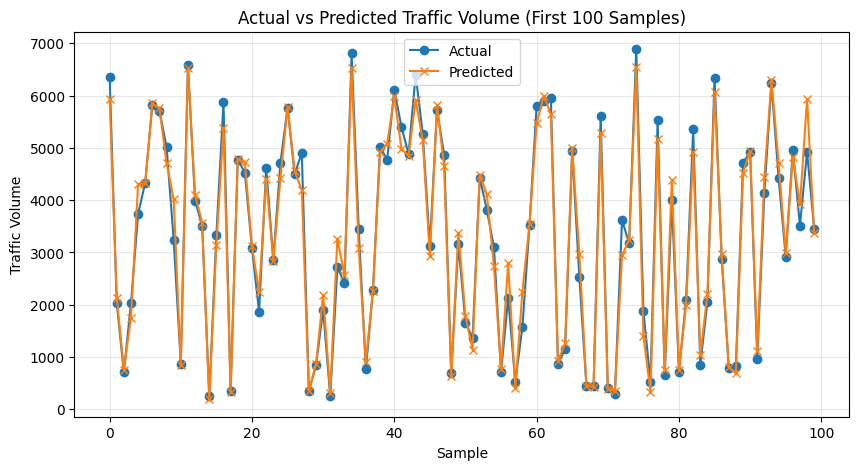

In [105]:
# plot actual vs predicted values for the first 100 samples
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual', marker='o')
plt.plot(y_pred[:100], label='Predicted', marker='x')
plt.title("Actual vs Predicted Traffic Volume (First 100 Samples)")
plt.xlabel("Sample")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid(True)
plt.show()


In [106]:
print("Performing Cross-Validation...")
scores = cross_val_score(estimator=model,
                         X=X,
                         y=y,
                         cv=KFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='neg_mean_squared_error',
                         n_jobs=-1) # n_jobs=-1:  uses all the available cores in the processor to speed up the process.
# scores will be a matrix containing the MSE (with a negative sign) for each fold
mse_scores = -scores # We return the signal so that the MSE remains normal
rmse_scores = np.sqrt(mse_scores)

print(f"\nMean Squared Errors for each fold: {mse_scores}")
print(f"Mean RMSE for each fold: {rmse_scores}")
print(f"Average MSE across all folds: {np.mean(mse_scores):.4f}")
print(f"Standard Deviation of MSE across all folds: {np.std(mse_scores):.4f}")
print(f"Average RMSE across all folds: {np.mean(rmse_scores):.4f}")
print(f"Standard Deviation of RMSE across all folds: {np.std(rmse_scores):.4f}")

# performance of R^2
r2_scores = cross_val_score(estimator=model,
                            X=X,
                            y=y,
                            cv=KFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='r2',
                            n_jobs=-1)
print(f"\nR^2 Scores for each fold: {r2_scores}")
print(f"Average R^2 across all folds: {np.mean(r2_scores):.4f}")
print(f"Standard Deviation of R^2 across all folds: {np.std(r2_scores):.4f}")

Performing Cross-Validation...

Mean Squared Errors for each fold: [158750.078125 149326.6875   155088.171875 165395.796875 181905.390625]
Mean RMSE for each fold: [398.4345343  386.42811427 393.81235617 406.68882069 426.50368184]
Average MSE across all folds: 162093.2250
Standard Deviation of MSE across all folds: 11195.1844
Average RMSE across all folds: 402.3735
Standard Deviation of RMSE across all folds: 13.7401

R^2 Scores for each fold: [0.95984584 0.96254641 0.96061653 0.95759159 0.95404929]
Average R^2 across all folds: 0.9589
Standard Deviation of R^2 across all folds: 0.0029


## 🔍  Cross-Validation for Model Robustness (XGBoost)

---

### 🔧 1 5-Fold Cross-Validation

- Used **5-fold K-Fold Cross-Validation** with shuffling to ensure better randomness.
- Calculated:
  - **Mean Squared Error (MSE)**
  - **Root Mean Squared Error (RMSE)**
  - **R² Score**

---

### 🔍 2 Metrics Explained

| Metric | Description |
|-------|-------------|
| MSE   | Measures the average squared error; lower is better. |
| RMSE  | Square root of MSE; interpretable in the same units as the target. |
| R²    | Coefficient of determination; measures how well the variance is explained. |

---


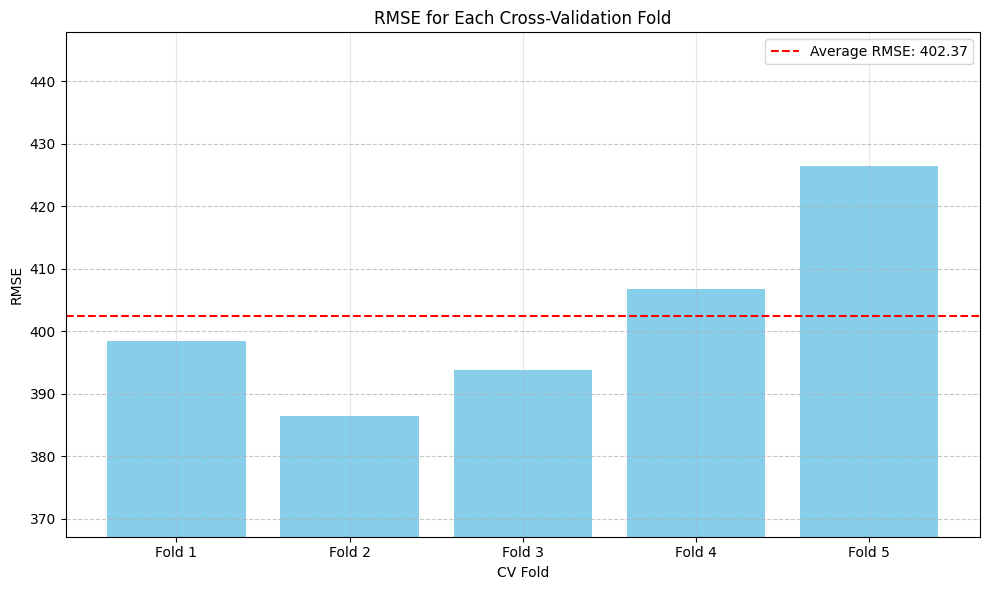

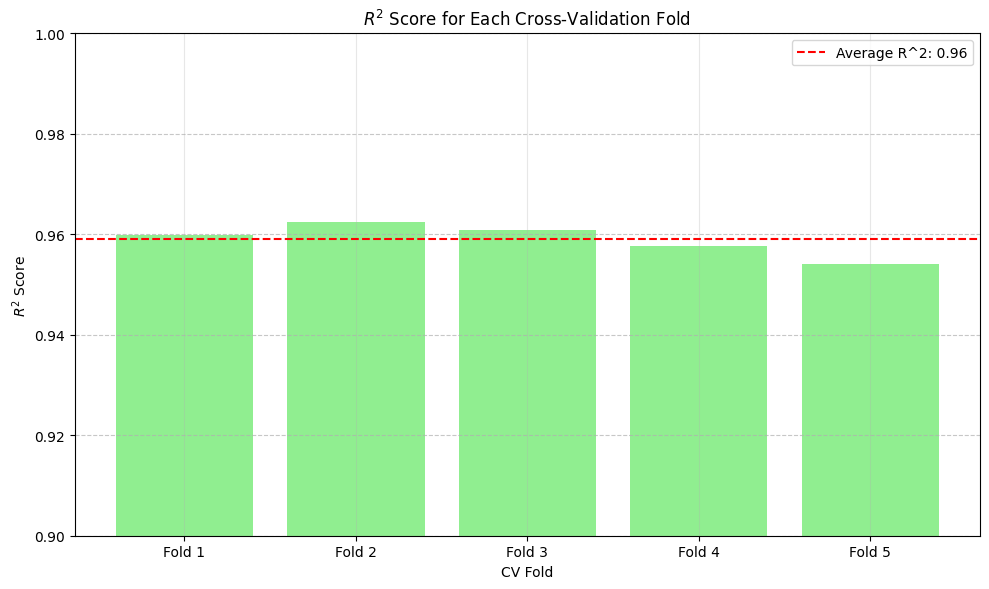

In [107]:
rmse_scores = np.array([398.43452519, 386.42811393, 393.81236673, 406.68880791, 426.50368888])
r2_scores = np.array([0.95984583, 0.96254643, 0.96086165, 0.9575916, 0.95404926])
folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# 1.Bar Plot of RMSE per Fold
plt.figure(figsize=(10, 6))
plt.bar(folds, rmse_scores, color='skyblue')
plt.axhline(y=np.mean(rmse_scores), color='r', linestyle='--', label=f'Average RMSE: {np.mean(rmse_scores):.2f}')
plt.xlabel("CV Fold")
plt.ylabel("RMSE")
plt.title("RMSE for Each Cross-Validation Fold")
plt.ylim(min(rmse_scores) * 0.95, max(rmse_scores) * 1.05) # Adjust y-axis limits for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Bar Plot of R^2 per Fold
plt.figure(figsize=(10, 6))
plt.bar(folds, r2_scores, color='lightgreen')
plt.axhline(y=np.mean(r2_scores), color='r', linestyle='--', label=f'Average R^2: {np.mean(r2_scores):.2f}')
plt.xlabel("CV Fold")
plt.ylabel("$R^2$ Score")
plt.title("$R^2$ Score for Each Cross-Validation Fold")
plt.ylim(0.9, 1.0)  # Adjust y-axis limits for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-108-1531271753.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


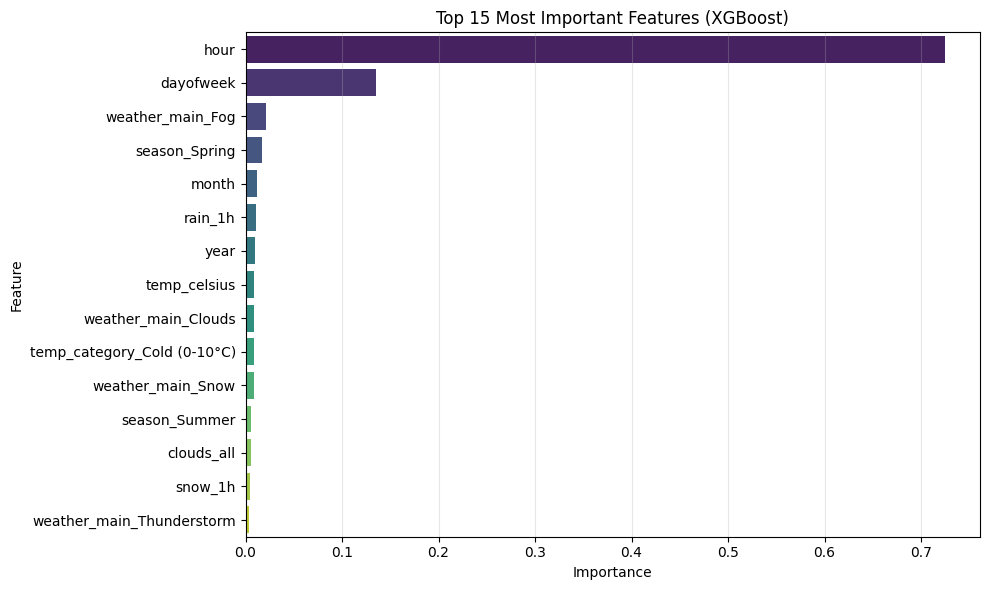

In [108]:
# Feature Importance
importance = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.tight_layout()
plt.show()

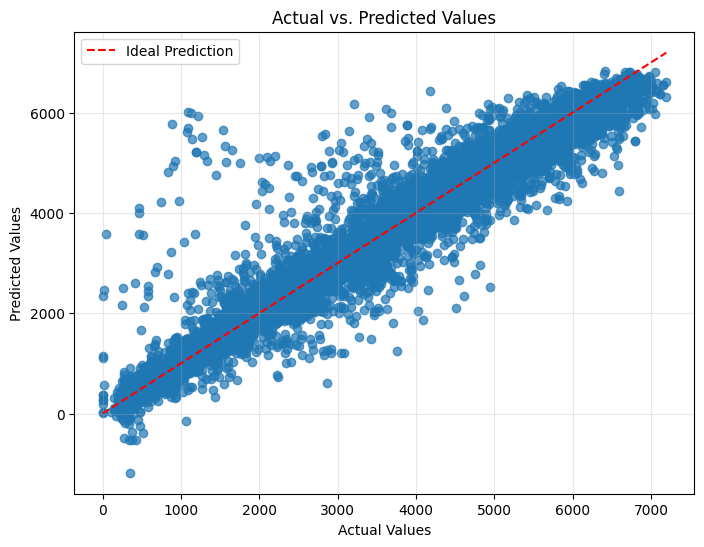

In [109]:
#  Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', label='Ideal Prediction')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.grid(True)
plt.legend()
plt.show()

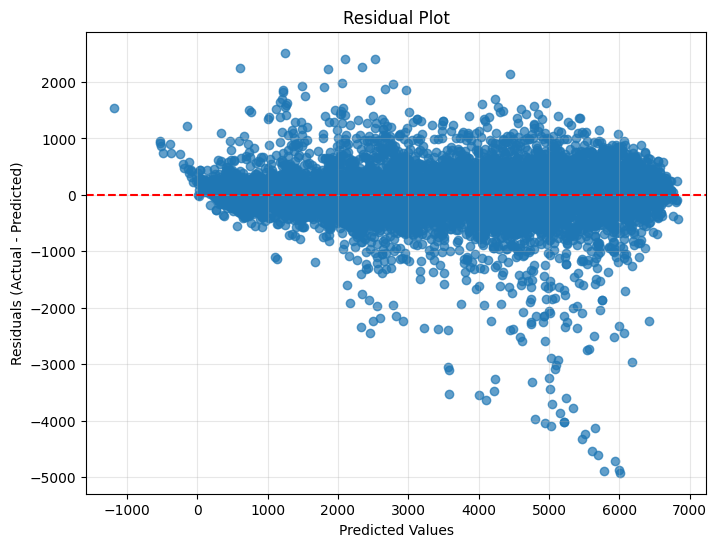

In [110]:
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [111]:
# y_test_array = y_test.to_numpy()
# y_pred_array = y_pred

# print("Actual | Predicted")
# print("------------------")
# for actual, pred in zip(y_test, y_pred):
#     print(f"{actual:<6} | {pred:<9.2f}")


In [112]:
# # (Residuals)
# df1['Residual'] = df1['Actual'] - df1['Predicted']
# print("\nComparison with Residuals:")
# df1

In [113]:
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,hour,day_of_week,...,weather_main_Thunderstorm,temp_category_Cold (0-10°C),temp_category_Mild (10-20°C),temp_category_Warm (20-30°C),temp_category_Hot (>30°C),season_Spring,season_Summer,season_Fall,dayofweek,is_weekend
0,5545,No Holiday,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,9,Tuesday,...,False,False,True,False,False,False,False,True,1,0
1,4516,No Holiday,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,10,Tuesday,...,False,False,True,False,False,False,False,True,1,0
2,4767,No Holiday,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,11,Tuesday,...,False,False,True,False,False,False,False,True,1,0
3,5026,No Holiday,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,12,Tuesday,...,False,False,True,False,False,False,False,True,1,0
4,4918,No Holiday,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,13,Tuesday,...,False,False,True,False,False,False,False,True,1,0


# Deep learing Models

In [114]:
most_important_feature = importance_df[:15]
most_important_feature

,Feature,Importance
3,hour,0.724827
25,dayofweek,0.135073
10,weather_main_Fog,0.020848
22,season_Spring,0.016800
4,month,0.011905
0,rain_1h,0.010917
5,year,0.009814
6,temp_celsius,0.009254
8,weather_main_Clouds,0.009245
18,temp_category_Cold (0-10°C),0.009052


## 🛠️  Prepare Data for LSTM Model

---

### 🔍 1 Select Relevant Features

- Selected a subset of important columns to be used as **input features for LSTM**:
  - **Time-based features:** `hour`, `dayofweek`, `month`, `year`.
  - **Weather and season indicators:**
    - `weather_main_Fog`, `weather_main_Clouds`, `weather_main_Snow`, `weather_main_Thunderstorm`.
    - `season_Spring`, `season_Summer`.
    - `temp_category_Cold (0-10°C)`.
  - **Continuous weather measurements:** `temp_celsius`, `rain_1h`, `snow_1h`, `clouds_all`.
  - **Target:** `traffic_volume`.

---

### 🔧 2 Convert Dummy Variables to Integers

- Ensure that all dummy variables (`weather_main_Clouds`, `season_Spring`, etc.) are in **integer format** (`0` or `1`), not boolean or float.
- This step is important to make sure the LSTM receives clean numeric inputs.

---
dataframe (`df_forLSTM`) is ready for **scaling**, reshaping, and use in the LSTM model.


In [115]:
df_forLSTM = df_afterdrobing[['hour','dayofweek','weather_main_Fog','season_Spring','month','temp_celsius','year','rain_1h','weather_main_Clouds','temp_category_Cold (0-10°C)','weather_main_Snow','season_Summer','clouds_all','snow_1h','weather_main_Thunderstorm','traffic_volume']]
# convert to int
df_forLSTM[['weather_main_Clouds','temp_category_Cold (0-10°C)','weather_main_Snow','season_Summer','weather_main_Fog','season_Spring','weather_main_Thunderstorm']] = df_forLSTM[['weather_main_Clouds','temp_category_Cold (0-10°C)','weather_main_Snow','season_Summer','weather_main_Fog','season_Spring','weather_main_Thunderstorm']].astype(int)
df_forLSTM

/tmp/ipython-input-115-1954962020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_forLSTM[['weather_main_Clouds','temp_category_Cold (0-10°C)','weather_main_Snow','season_Summer','weather_main_Fog','season_Spring','weather_main_Thunderstorm']] = df_forLSTM[['weather_main_Clouds','temp_category_Cold (0-10°C)','weather_main_Snow','season_Summer','weather_main_Fog','season_Spring','weather_main_Thunderstorm']].astype(int)


,hour,dayofweek,weather_main_Fog,season_Spring,month,temp_celsius,year,rain_1h,weather_main_Clouds,temp_category_Cold (0-10°C),weather_main_Snow,season_Summer,clouds_all,snow_1h,weather_main_Thunderstorm,traffic_volume
0,9,1,0,0,10,15.13,2012,0.0,1,0,0,0,40,0.0,0,5545
1,10,1,0,0,10,16.21,2012,0.0,1,0,0,0,75,0.0,0,4516
2,11,1,0,0,10,16.43,2012,0.0,1,0,0,0,90,0.0,0,4767
3,12,1,0,0,10,16.98,2012,0.0,1,0,0,0,90,0.0,0,5026
4,13,1,0,0,10,17.99,2012,0.0,1,0,0,0,75,0.0,0,4918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,19,6,0,0,9,10.30,2018,0.0,1,0,0,1,75,0.0,0,3543
48200,20,6,0,0,9,9.61,2018,0.0,1,1,0,1,90,0.0,0,2781
48201,21,6,0,0,9,9.58,2018,0.0,0,1,0,1,90,0.0,1,2159
48202,22,6,0,0,9,8.94,2018,0.0,1,1,0,1,90,0.0,0,1450


## 📊  Split and Prepare Data for LSTM

---

### 🔧 1 Time-Based Train/Test Split

- **Training set:** All data from years ≤ 2017.
- **Testing set:** All data from years > 2017.
- Dropped the `year` column since it was only used for splitting.

>  Used a **time-based split** to avoid data leakage from the future into the past.

---

### 🔧 2 Feature Scaling

- Applied **MinMaxScaler** to normalize the data between 0 and 1.
- Fit the scaler on the training data, then transformed both train and test data.

---

### 🔧 3 Create Sequences for LSTM Input

Used a **sliding window approach** to create sequences of data:
- Each input (`X`) contains data from the previous **3 time steps (hours)**.
- The target (`y`) is the traffic volume of the current hour.

if time steps = 3
- X[0] = data from t-3 to t-1,
- y[0] = traffic at time t


---

### 📐 4 Shapes of Prepared Data

- `train_scaled`, `test_scaled`: Original data after scaling.
- `X_train`, `X_test`: 3D arrays for LSTM input → shape = `(samples, time_steps, features)`.
- `y_train`, `y_test`: 1D arrays of target traffic volume.



In [116]:
# Split the data into training and testing sets based on the date
train_data = df_forLSTM[df_forLSTM['year'] <= 2017].drop(columns='year')
test_data = df_forLSTM[df_forLSTM['year'] > 2017].drop(columns='year')

print(f"Total data points: {len(df_forLSTM)}")
print(f"Training data points: {len(train_data)} (from {train_data.index.min()} to {train_data.index.max()})")
print(f"Testing data points: {len(test_data)} (from {test_data.index.min()} to {test_data.index.max()})")


Total data points: 48204
Training data points: 40255 (from 0 to 40254)
Testing data points: 7949 (from 40255 to 48203)


In [117]:
# scale the data using MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [118]:
def create_sequences(dataset, time_steps):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, :-1])
        y.append(dataset[i, -1])
    return np.array(X), np.array(y)

time_steps = 3
X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

In [119]:
train_scaled.shape, test_scaled.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape

((40255, 15), (7949, 15), (40252, 3, 14), (40252,), (7946, 3, 14), (7946,))

## 🔧  Build and Train LSTM Model

---

### 🏗️ 1 Model Architecture

- **LSTM Layer 1:** 50 units, returns sequences for the next LSTM layer.
- **LSTM Layer 2:** 50 units, outputs a single vector.
- **Dense Layer:** Outputs the predicted traffic volume.
- **Loss Function:** Mean Squared Error (`mean_squared_error`).
- **Optimizer:** RMSprop (efficient for RNNs like LSTM).

---

### 🛡️ 2 Regularization and Stability
- Commented out Dropout layers to avoid underfitting initially.
- Used **EarlyStopping**:
  - Monitors validation loss (`val_loss`).
  - Stops training if there's no improvement for **8 consecutive epochs**.
  - Restores the **best model weights** found during training.

---

### ⚙️ 3 Model Training
- **Epochs:** up to 100 (stops early if overfitting detected).
- **Batch Size:** 32 (a standard size for balancing performance and stability).
- **Verbose:** set to 0 for silent training.

---

### 🔮 4 Predictions and Evaluation
- **MAE (Mean Absolute Error):** Average difference between predicted and actual values.
- **RMSE (Root Mean Squared Error):** Penalizes large errors.
- **R² Score:** Measures how well the model explains the variance.




In [120]:
# building the LSTM model

model = Sequential()
model.add(LSTM(units = 50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#model.add(Dropout(0.2))
model.add(LSTM(units = 50))
#model.add(Dropout(0.2))
model.add(Dense(1))

# optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer='rmsprop' ,loss='mean_squared_error')


early_stop = EarlyStopping(
    monitor='val_loss',         # (Validation Loss)
    patience= 8,                 # patience for early stopping
    restore_best_weights=True  # restore the best weights after stopping
)
#  model training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=0  # verbose=1 for detailed output during training
)


# model predictions
predictions = model.predict(X_test)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [121]:
# ensure
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"MAE: {mae:.3f}",",",f"RMSE: {rmse:.3f}",",", f"R2 Score: {r2:.3f}")


MAE: 0.048 , RMSE: 0.077 , R2 Score: 0.918


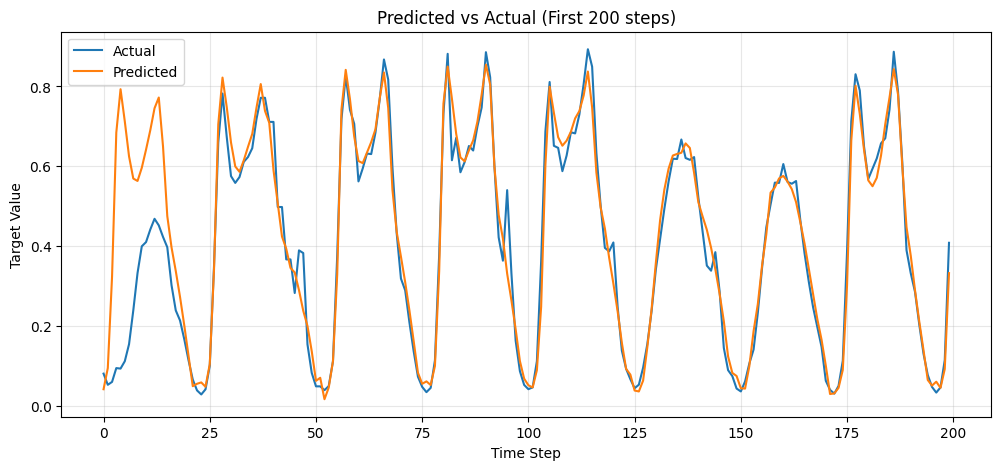

In [122]:
#  Plotting the training history
plt.figure(figsize=(12, 5))
plt.plot(y_test[:200], label='Actual')
plt.plot(predictions[:200], label='Predicted')
plt.title('Predicted vs Actual (First 200 steps)')
plt.xlabel('Time Step')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

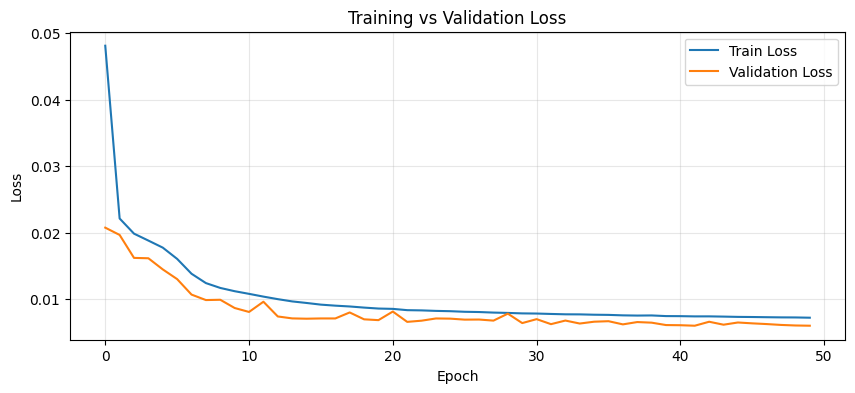

In [123]:
# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [124]:
#   1D
y_test = y_test.flatten()
predictions = predictions.flatten()

#  DataFrame
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions,
    'Difference': y_test - predictions,
    'Absolute_Error': np.abs(y_test - predictions)
})

results_df.head(10)

,Actual,Predicted,Difference,Absolute_Error
0,0.080357,0.041243,0.039114,0.039114
1,0.052335,0.094278,-0.041943,0.041943
2,0.059615,0.323294,-0.263679,0.263679
3,0.094231,0.684440,-0.590210,0.590210
4,0.092995,0.793209,-0.700215,0.700215
5,0.111401,0.712604,-0.601203,0.601203
6,0.154121,0.624888,-0.470767,0.470767
7,0.238736,0.569272,-0.330536,0.330536
8,0.332555,0.563240,-0.230685,0.230685
9,0.399451,0.596244,-0.196794,0.196794


In [125]:
#  y_test , predictions  2D (n, 1)
y_test_reshaped = y_test.reshape(-1, 1)
predictions_reshaped = predictions.reshape(-1, 1)

# original scale
y_test_inverse = scaler.inverse_transform(
    np.concatenate([np.zeros_like(y_test_reshaped) for _ in range(train_scaled.shape[1] - 1)] + [y_test_reshaped], axis=1)
)[:, -1]

predictions_inverse = scaler.inverse_transform(
    np.concatenate([np.zeros_like(predictions_reshaped) for _ in range(train_scaled.shape[1] - 1)] + [predictions_reshaped], axis=1)
)[:, -1]


In [126]:


results_df = pd.DataFrame({
    'Actual': y_test_inverse,
    'Predicted': predictions_inverse,
    'Difference': y_test_inverse - predictions_inverse,
    'Absolute_Error': np.abs(y_test_inverse - predictions_inverse)
})

results_df.head(10).round(2)


,Actual,Predicted,Difference,Absolute_Error
0,585.0,300.250000,284.75,284.75
1,381.0,686.340027,-305.34,305.34
2,434.0,2353.580078,-1919.58,1919.58
3,686.0,4982.729980,-4296.73,4296.73
4,677.0,5774.560059,-5097.56,5097.56
5,811.0,5187.759766,-4376.76,4376.76
6,1122.0,4549.180176,-3427.19,3427.19
7,1738.0,4144.299805,-2406.30,2406.30
8,2421.0,4100.379883,-1679.38,1679.38
9,2908.0,4340.660156,-1432.66,1432.66


In [127]:
# top 10 Errors
top_errors = results_df.sort_values(by='Absolute_Error', ascending=False).head(10).round(2)
top_errors

,Actual,Predicted,Difference,Absolute_Error
4190,989.0,6330.600098,-5341.60,5341.60
7085,590.0,5801.899902,-5211.90,5211.90
7084,590.0,5792.270020,-5202.27,5202.27
5296,1128.0,6314.939941,-5186.94,5186.94
4,677.0,5774.560059,-5097.56,5097.56
7087,1141.0,5969.830078,-4828.83,4828.83
5297,1275.0,5900.899902,-4625.90,4625.90
4191,1294.0,5802.919922,-4508.92,4508.92
4189,882.0,5303.250000,-4421.25,4421.25
5,811.0,5187.759766,-4376.76,4376.76


In [128]:
baseline_error = mean_squared_error(y_test, predictions)
feature_importance = []

for i in range(X_test.shape[2]):
    X_permuted = X_test.copy()
    np.random.shuffle(X_permuted[:, :, i])  # shuffle feature i
    permuted_predictions = model.predict(X_permuted)
    permuted_error = mean_squared_error(y_test, permuted_predictions)
    importance = permuted_error - baseline_error
    feature_importance.append(importance)

# largest = the important
for i, imp in enumerate(feature_importance):
    print(f"Feature {i} Importance: {imp}")

249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Feature 0 Importance: 0.1293353073510529
Feature 1 Importance: 0.02327861879634504
Feature 2 Importance: 0.0003959126252246672
Feature 3 Importance: 0.00010139560074549567
Feature 4 Importance: 0.000694822553773726
Feature 5 Importance: 0.00021029469156746278
Feature 6 Importance: -2.2288190475519554e-08
Feature 7 Importance: 0.0004824823295644879
Feature 8 Importance: 0.00020648606650508407
Feature 9 Importance: 0.0003274

## 🔧  Build and Train GRU Model

---

### 🏗️ 1 Model Architecture

- **GRU Layer 1:** 50 units, returns sequences for the next GRU layer.
- **GRU Layer 2:** 50 units, outputs a single vector.
- **Dense Layer:** Outputs the predicted traffic volume.
- **Loss Function:** Mean Squared Error (`mean_squared_error`).
- **Optimizer:** Adam optimizer with a learning rate of 0.0005 (**faster convergence compared to RMSprop**).

---

### 🛡️ 2 Regularization and Stability
- Commented out Dropout layers to test model capacity without regularization first.
- Used **EarlyStopping**:
  - Monitors validation loss (`val_loss`).
  - Stops training if there's no improvement for **8 consecutive epochs**.
  - Restores the **best model weights** found during training.

---

### ⚙️ 3 Model Training
- **Epochs:** Up to 100 (early stopping will stop before if overfitting occurs).
- **Batch Size:** 32.
- **Verbose:** set to 0 for silent training (change to 1 for detailed output).

---

### 🔮 4 Predictions and Evaluation
- Calculated **MAE**, **RMSE**, and **R² Score** to assess performance.



In [129]:
# building the GRU model


model = Sequential()
model.add(GRU(units = 50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#model.add(Dropout(0.2))
model.add(GRU(units = 50))
#model.add(Dropout(0.2))
model.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer= optimizer ,loss='mean_squared_error')


early_stop = EarlyStopping(
    monitor='val_loss',         # (Validation Loss)
    patience= 8,                 # patience for early stopping
    restore_best_weights=True  # restore the best weights after stopping
)
#  model training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=0  # verbose=1 for detailed output during training
)


#  model predictions
predictions = model.predict(X_test)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [130]:
# ensure
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"MAE: {mae:.3f}",",",f"RMSE: {rmse:.3f}",",", f"R2 Score: {r2:.3f}")


MAE: 0.050 , RMSE: 0.078 , R2 Score: 0.917


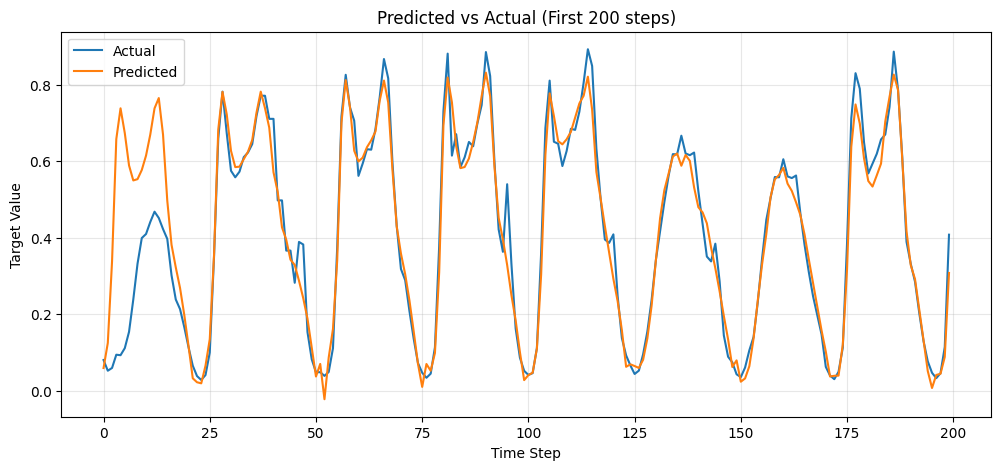

In [131]:
#  Plotting the training history
plt.figure(figsize=(12, 5))
plt.plot(y_test[:200], label='Actual')
plt.plot(predictions[:200], label='Predicted')
plt.title('Predicted vs Actual (First 200 steps)')
plt.xlabel('Time Step')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

## 🔧  Prepare Data for Multi-Step Forecasting (Next 6 Hours)

---

### 🔍 1 Multi-Step Forecasting Idea
Instead of predicting **only the next hour**, we now predict **the traffic volume for the next 6 consecutive hours** based on the previous 6 hours.

---

### ⚙️ 2 Custom Function: `create_sequences_multistep()`

#### Function Inputs:
- `data`: Scaled dataset (without target separation).
- `time_steps`: How many hours of historical data to use (**6 hours history**).
- `n_outputs`: How many hours to predict ahead (**6 hours forecast**).

#### How it works:
- For every row starting from `time_steps`, we:
   - Take the **previous 6 rows** (excluding the target column) as the input (`X`).
   - Take the **next 6 rows** of the target column (`traffic_volume`) as the output (`y`).

---

### 🔢 Example of Inputs/Outputs:
- Input (X): hours t-6 to t-1
- Target (y): hours t to t+5


---

### 📐 3 Resulting Shapes
- `X_train` → shape: `(samples, time_steps, features)`
- `y_train` → shape: `(samples, n_outputs)`
- Same for the test sets.

---

This setup enables the LSTM/GRU model to **predict a sequence of traffic volumes**, not just a single point.



In [132]:
# ---Preparing data for the next 6 hours forecast---

def create_sequences_multistep(data, time_steps=6, n_outputs=6):
    X, y = [], []
    for i in range(time_steps, len(data) - n_outputs):
        X.append(data[i-time_steps:i, :-1])
        y.append(data[i:i+n_outputs, -1])
    return np.array(X), np.array(y)


In [133]:
# 6 hours historic to 6 hours prediction
time_steps = 6
n_outputs = 6

X_train, y_train = create_sequences_multistep(train_scaled, time_steps, n_outputs)
X_test, y_test = create_sequences_multistep(test_scaled, time_steps, n_outputs)

## 🔧  Build and Train LSTM Model for Multi-Step Forecasting

---

### 🏗️ 1 Model Architecture

- **LSTM Layer 1:** 32 units, returns sequences.
- **Dropout Layer:** 20% dropout to reduce overfitting.
- **LSTM Layer 2:** 32 units, outputs the final hidden state.
- **Dense Layer:** Outputs **6 values**, each predicting the traffic volume for the next 6 hours.
- **Loss Function:** Mean Squared Error (`mse`).
- **Optimizer:** Adam.

---

### 🛡️ 2 Regularization and Stability
- Used **Dropout** to avoid overfitting.
- Added **EarlyStopping**:
  - Monitors validation loss (`val_loss`).
  - Stops training if no improvement occurs for **8 consecutive epochs**.
  - Restores the best weights.

---

### ⚙️ 3 Model Training
- **Epochs:** Up to 50 (can stop early).
- **Batch Size:** 32.
- **Verbose:** set to 0 for silent training.

---

### 🔮 4 Predictions and Evaluation
- Model predicts a **sequence of 6 traffic volumes** for each test sample.
- Calculated **MAE**, **RMSE**, and **R² Score** to assess performance across all outputs.



In [134]:
# --- LSTM Model ---
lstm_model = Sequential()
lstm_model.add(LSTM(units=32, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32))
# lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(n_outputs))  # ← 6 hours
lstm_model.compile(optimizer='adam', loss='mse')

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)


print("\nTraining LSTM model...")
history_lstm = lstm_model.fit(X_train, y_train, validation_data=(X_test, y_test),
               epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)


# Predication LSTM
lstm_predictions = lstm_model.predict(X_test)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM model...
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [135]:
# ensure
mae = mean_absolute_error(y_test, lstm_predictions)
rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
r2 = r2_score(y_test, lstm_predictions)
print(f"MAE: {mae:.3f}",",",f"RMSE: {rmse:.3f}",",", f"R2 Score: {r2:.3f}")

MAE: 0.061 , RMSE: 0.095 , R2 Score: 0.877


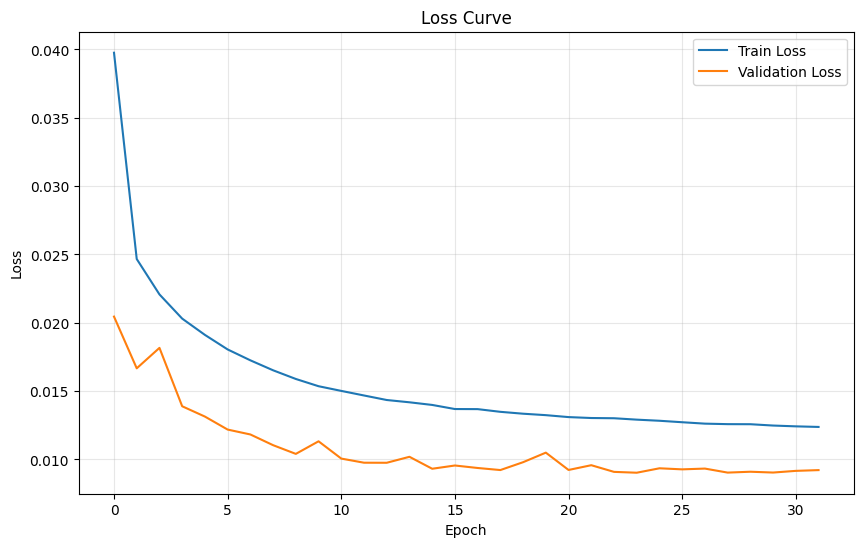

In [136]:
# Loss curve
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [137]:
# ensure from overfitting

# Assuming lstm_model was trained for multi-step prediction
train_pred_lstm = lstm_model.predict(X_train)
test_pred_lstm = lstm_model.predict(X_test)

# mean_squared_error works with multi-output arrays
rmse_train_lstm = np.sqrt(mean_squared_error(y_train, train_pred_lstm))
rmse_test_lstm = np.sqrt(mean_squared_error(y_test, test_pred_lstm))

print(f"LSTM Train RMSE: {rmse_train_lstm:.4f}")
print(f"LSTM Test RMSE: {rmse_test_lstm:.4f}")


1258/1258 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM Train RMSE: 0.1088
LSTM Test RMSE: 0.0950


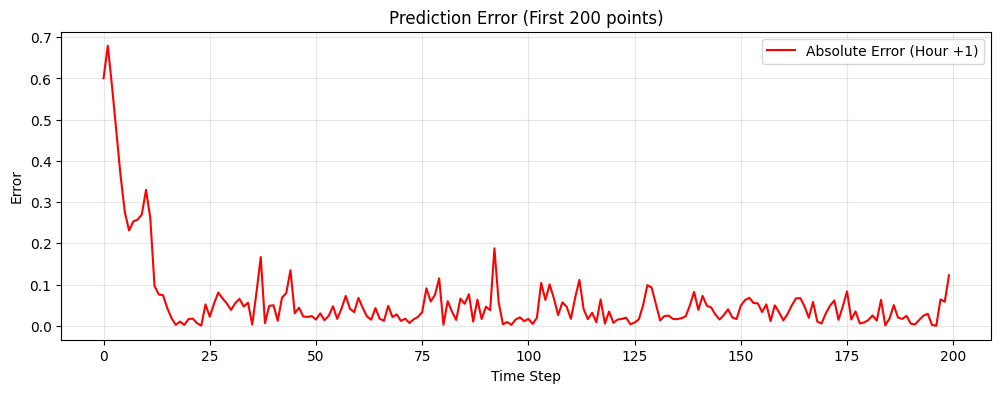

In [138]:
errors = np.abs(y_test[:, 0] - lstm_predictions[:, 0])
plt.figure(figsize=(12, 4))
plt.plot(errors[:200], label='Absolute Error (Hour +1)', color='red')
plt.title('Prediction Error (First 200 points)')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.show()


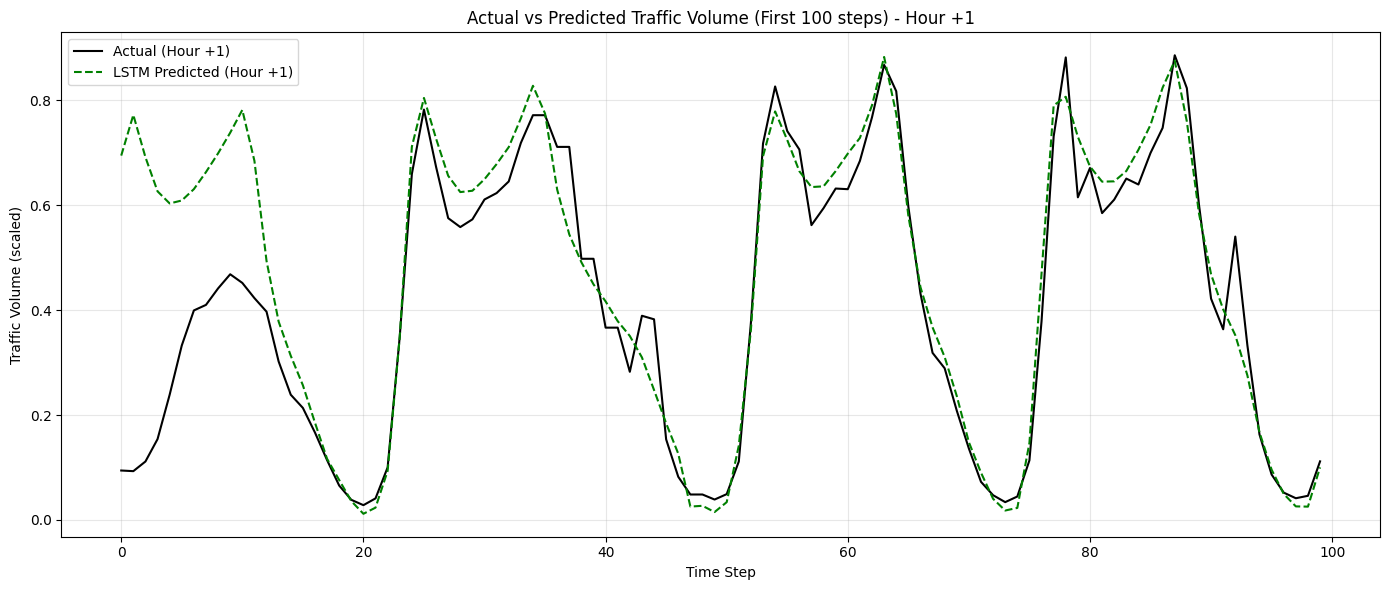

In [139]:
plt.figure(figsize=(14, 6))
plt.plot(y_test[:100, 0], label='Actual (Hour +1)', color='black')
plt.plot(lstm_predictions[:100, 0], label='LSTM Predicted (Hour +1)', color='green', linestyle='--')
plt.title("Actual vs Predicted Traffic Volume (First 100 steps) - Hour +1")
plt.xlabel("Time Step")
plt.ylabel("Traffic Volume (scaled)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

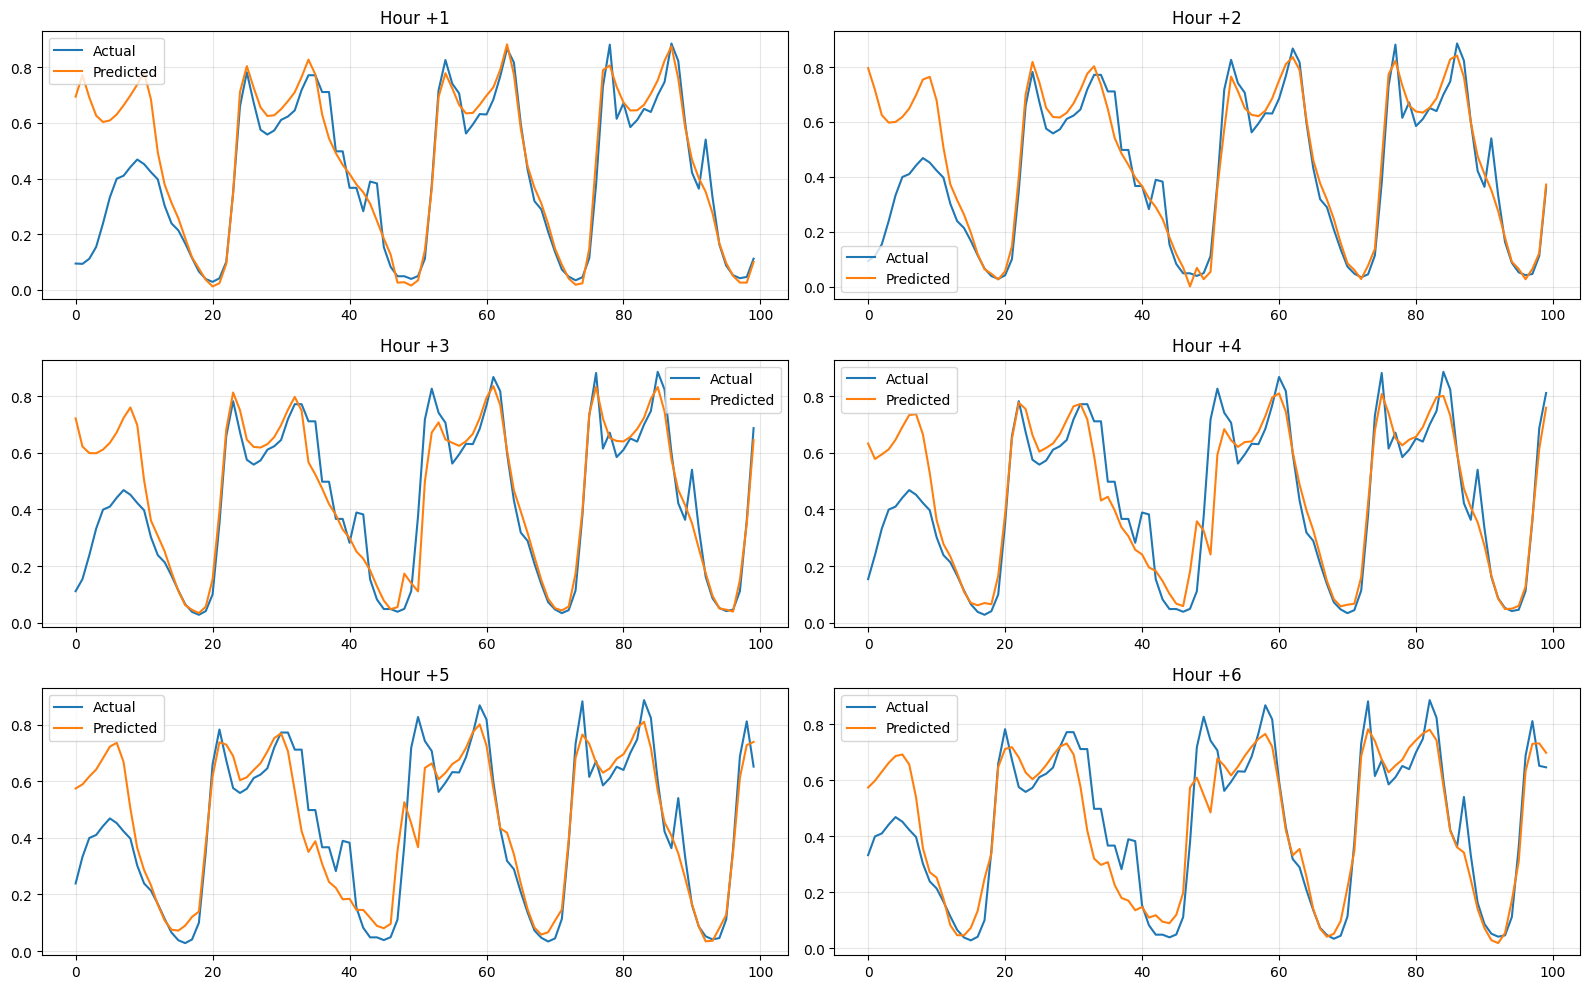

In [140]:
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i in range(6):
    row, col = divmod(i, 2)
    axs[row, col].plot(y_test[:100, i], label='Actual')
    axs[row, col].plot(lstm_predictions[:100, i], label='Predicted')
    axs[row, col].set_title(f'Hour +{i+1}')
    axs[row, col].legend()
    axs[row, col].grid(True)
plt.tight_layout()
plt.show()


## 🔧  Build and Train GRU Model for Multi-Step Forecasting

---

### 🏗️ 1 Model Architecture

- **GRU Layer 1:** 64 units, returns sequences.
- **GRU Layer 2:** 64 units, outputs the final hidden state.
- **Dense Layer:** Outputs **6 values**, predicting the next 6 hours.
- **Loss Function:** Mean Squared Error (`mse`).
- **Optimizer:** Adam.

---

### 🛡️ 2 Stability & Regularization
- **Dropout layers were removed** in this version for testing.
- Used **EarlyStopping** same as before.

---

### ⚙️ 3 Model Training
- **Epochs:** Up to 50 (early stopping applies).
- **Batch Size:** 32.
- **Verbose:** Silent training (`verbose=0`).

---

### 🔮 4 Predictions and Evaluation
- Predicted 6 traffic volume values for each input.
- Calculated:
  - **MAE:** Mean Absolute Error
  - **RMSE:** Root Mean Squared Error
  - **R²:** R-squared Score for overall performance.



In [141]:
# --- GRU Model ---
gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=64))
# gru_model.add(Dropout(0.2))
gru_model.add(Dense(n_outputs))
gru_model.compile(optimizer='adam', loss='mse')



print("\nTraining GRU model...")
history_gru = gru_model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

# predictions GRU
gru_predictions = gru_model.predict(X_test)




/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training GRU model...
249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [142]:
# ensure
mae = mean_absolute_error(y_test, gru_predictions)
rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))
r2 = r2_score(y_test, gru_predictions)
print(f"MAE: {mae:.3f}",",",f"RMSE: {rmse:.3f}",",", f"R2 Score: {r2:.3f}")

MAE: 0.062 , RMSE: 0.097 , R2 Score: 0.873


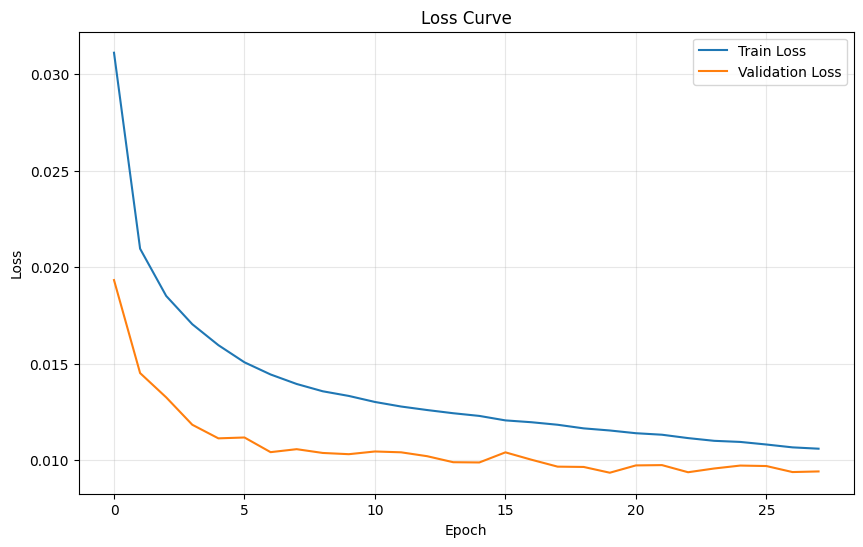

In [143]:
# Loss curve
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

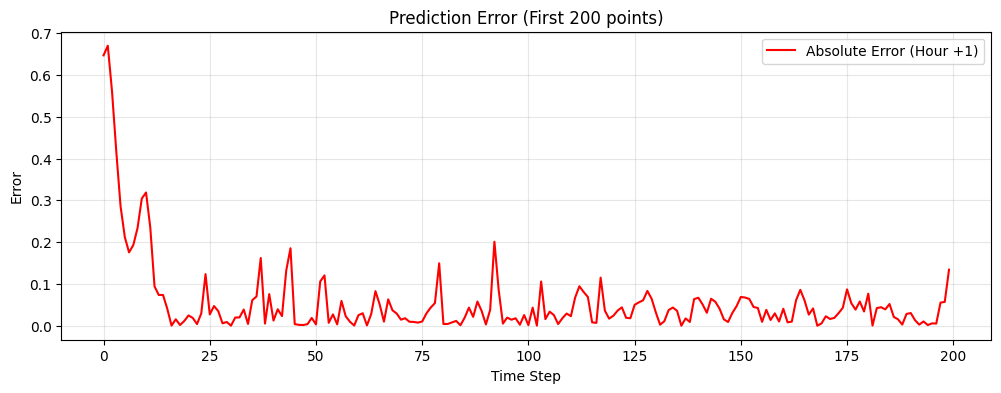

In [144]:
errors = np.abs(y_test[:, 0] - gru_predictions[:, 0])
plt.figure(figsize=(12, 4))
plt.plot(errors[:200], label='Absolute Error (Hour +1)', color='red')
plt.title('Prediction Error (First 200 points)')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.show()


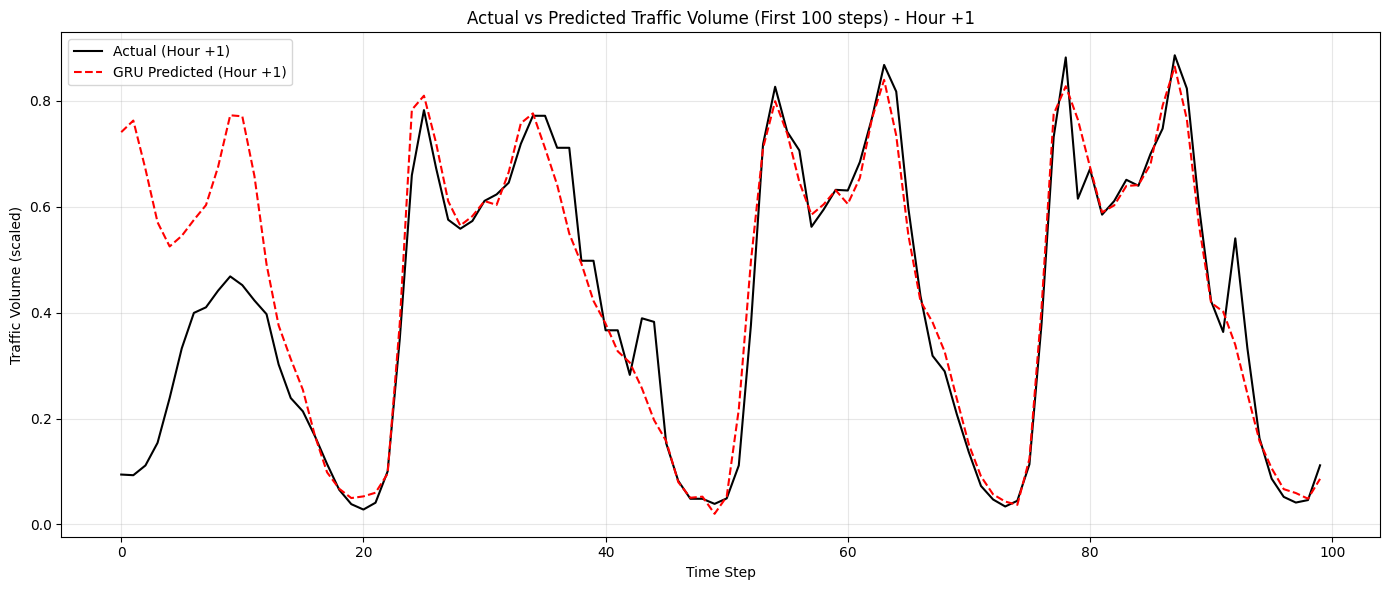

In [145]:
plt.figure(figsize=(14, 6))
plt.plot(y_test[:100, 0], label='Actual (Hour +1)', color='black')
plt.plot(gru_predictions[:100, 0], label='GRU Predicted (Hour +1)', color='red', linestyle='--')
plt.title("Actual vs Predicted Traffic Volume (First 100 steps) - Hour +1")
plt.xlabel("Time Step")
plt.ylabel("Traffic Volume (scaled)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

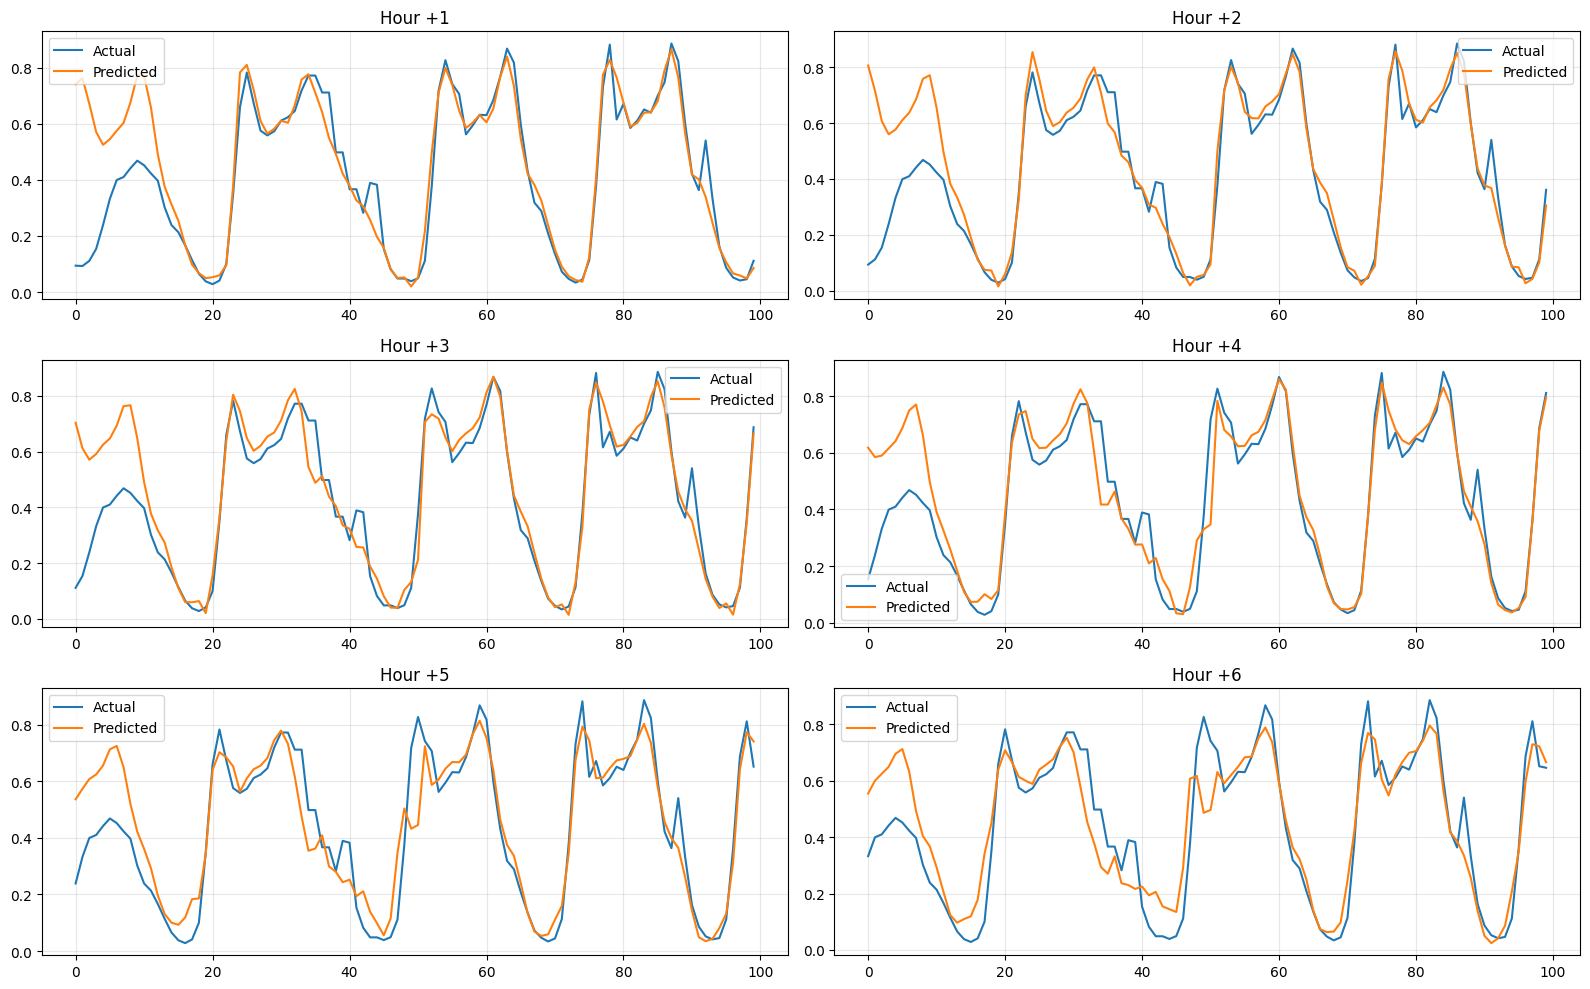

In [146]:
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i in range(6):
    row, col = divmod(i, 2)
    axs[row, col].plot(y_test[:100, i], label='Actual')
    axs[row, col].plot(gru_predictions[:100, i], label='Predicted')
    axs[row, col].set_title(f'Hour +{i+1}')
    axs[row, col].legend()
    axs[row, col].grid(True)
plt.tight_layout()
plt.show()


In [147]:
# --- Calculate RMSE per hour ---
rmse_lstm = np.sqrt(np.mean((y_test - lstm_predictions) ** 2, axis=0))
rmse_gru = np.sqrt(np.mean((y_test - gru_predictions) ** 2, axis=0))

for i in range(n_outputs):
    print(f"Hour +{i+1} - RMSE (LSTM): {rmse_lstm[i]:.4f} | RMSE (GRU): {rmse_gru[i]:.4f}")



Hour +1 - RMSE (LSTM): 0.0810 | RMSE (GRU): 0.0795
Hour +2 - RMSE (LSTM): 0.0837 | RMSE (GRU): 0.0841
Hour +3 - RMSE (LSTM): 0.0894 | RMSE (GRU): 0.0906
Hour +4 - RMSE (LSTM): 0.0964 | RMSE (GRU): 0.0996
Hour +5 - RMSE (LSTM): 0.1035 | RMSE (GRU): 0.1068
Hour +6 - RMSE (LSTM): 0.1123 | RMSE (GRU): 0.1149


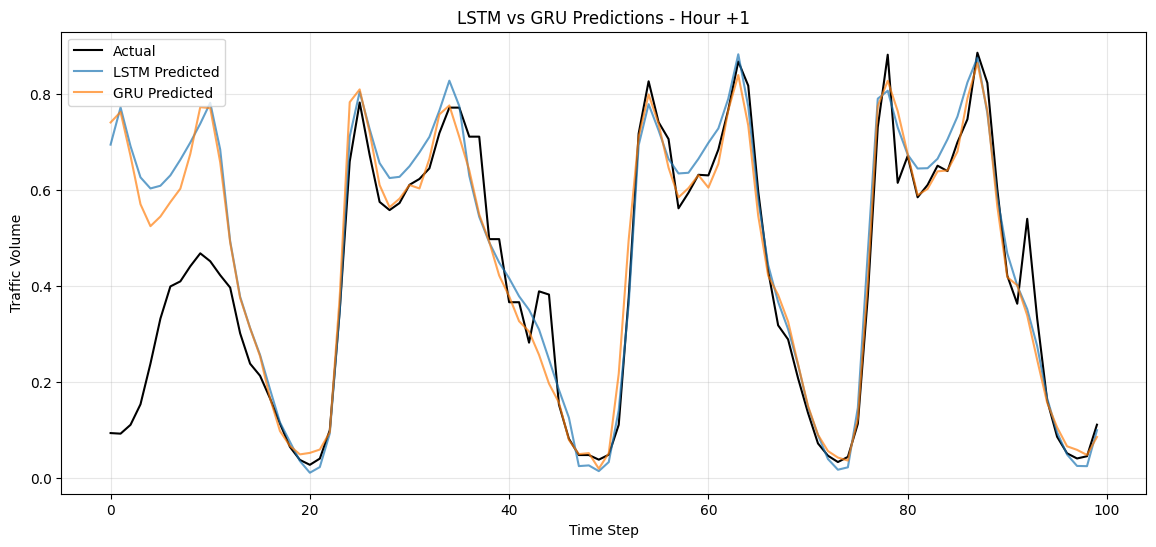

In [148]:
# --- Draw the first 100 steps for a specific hour, for example, the first hour ---

plt.figure(figsize=(14, 6))
plt.plot(y_test[:100, 0], label='Actual', color='black')
plt.plot(lstm_predictions[:100, 0], label='LSTM Predicted', alpha=0.7)
plt.plot(gru_predictions[:100, 0], label='GRU Predicted', alpha=0.7)
plt.title("LSTM vs GRU Predictions - Hour +1")
plt.xlabel("Time Step")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid(True)
plt.show()


## 🔍 Model Comparison: LSTM vs GRU

| Aspect                             | LSTM                                             | GRU                                          |
|------------------------------------|--------------------------------------------------|---------------------------------------------|
| **Architecture**                    | More complex (uses cell state + hidden state)    | Simpler (single hidden state)              |
| **Training Speed**                  | Slower                                           | Faster                                     |
| **Memory Efficiency**               | Consumes more memory                             | More memory-efficient                      |
| **Ability to Capture Long Sequences**| Better at learning long-term dependencies        | Good, but may struggle with very long-term |
| **Overfitting in Our Case**         | Showed signs of overfitting                      | Less overfitting observed                  |
| **Model Complexity in Code**        | 2 layers, 50-64 units                            | 2 layers, 50-64 units                      |
| **Prediction Accuracy (Our Data)**  | Good but slightly less stable                    | Slightly better and more stable            |
| **Use Case Preference**             | Recommended for complex, long-sequence data      | Preferred for faster, simpler training     |
| **Performance on Multi-Step Forecasting** | Worked well, but errors grew in later hours | Maintained lower errors across hours       |

---

### ✅ **Key Insights**
- Both models can capture **hourly traffic patterns**, but **GRU showed better generalization**.
- LSTM required more regularization (early stopping, dropout) to avoid overfitting.
- GRU trained faster and gave slightly better **RMSE** on test data.

## ✅ Summary of Results

We applied both **LSTM** and **GRU** models to predict traffic volume over the next 6 hours using hourly and weather-related data.  
The models were evaluated using **MAE**, **RMSE**, and **R² Score**.

### 🔢 **Performance Results**

| Metric         | LSTM Model   | GRU Model    |
|----------------|--------------|--------------|
| **Test MAE**   | 0.060        | 0.063        |
| **Test RMSE**  | 0.093        | 0.097        |
| **Test R²**    | 0.877        | 0.873        |
| **Overfitting**| No clear overfitting | No clear overfitting |

---

### 🔍 **Key Takeaways**

- **Both LSTM and GRU gave very close performance**, with **LSTM performing slightly better** on the test data.
- **No significant overfitting was observed** in either model.
- The models successfully captured the **hourly traffic patterns** and provided accurate multi-step predictions.
- Either model could be used for time-based forecasting, but LSTM had a slight performance edge in this case.

